<a href="https://colab.research.google.com/github/Hindabuzarour/Hindabuzarour/blob/main/Copy_of_Project_1_Part_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Prediction of Product Sales

### Project 1 - part 3
- Hind Abuzarour

# Loading Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
fpath= '/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/01-Fundamentals/Week02/Data/sales_predictions_2023.csv'
df_sales = pd.read_csv(fpath)
# view first 5 rows
df_sales.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
# data summary
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


# Data Cleaning
- number of rows: 8523
- number of columns: 12

In [5]:
# data types for each variables
df_sales.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object


- numerical variables 5
- categorical variables 7

In [6]:
dfstr_clo=df_sales.select_dtypes("object").value_counts()
dfstr_clo

Item_Identifier  Item_Fat_Content  Item_Type              Outlet_Identifier  Outlet_Size  Outlet_Location_Type  Outlet_Type      
DRA12            LF                Soft Drinks            OUT035             Small        Tier 2                Supermarket Type1    1
FDV27            Regular           Meat                   OUT019             Small        Tier 1                Grocery Store        1
FDV32            Low Fat           Fruits and Vegetables  OUT035             Small        Tier 2                Supermarket Type1    1
                                                          OUT019             Small        Tier 1                Grocery Store        1
                                                          OUT018             Medium       Tier 3                Supermarket Type2    1
                                                                                                                                    ..
FDJ33            Regular           Snack Foods            OUT018             Medium       Tier 3                Supermarket Type2    1
FDJ32            Low Fat           Fruits and Vegetables  OUT027             Medium       Tier 3                Supermarket Type3    1
                                                          OUT013             High         Tier 3                Supermarket Type1    1
                 LF                Fruits and Vegetables  OUT046             Small        Tier 1                Supermarket Type1    1
NCZ54            Low Fat           Household              OUT049             Medium       Tier 1                Supermarket Type1    1
Name: count, Length: 6113, dtype: int64

In [7]:
df_sales.select_dtypes("number").value_counts()

Item_Weight  Item_Visibility  Item_MRP  Outlet_Establishment_Year  Item_Outlet_Sales
4.555        0.034329         110.1544  1987                       1230.3984            1
15.600       0.042180         174.7054  1998                       175.1054             1
             0.081104         112.3544  1997                       1006.6896            1
             0.081036         112.3544  1987                       2572.6512            1
             0.066830         185.5924  1999                       3146.5708            1
                                                                                       ..
9.800        0.090390         192.1478  1987                       2324.9736            1
             0.073290         120.8098  2007                       1325.6078            1
             0.072991         121.6098  1999                       1566.6274            1
             0.072864         118.6098  2004                       843.5686             1
21.350       0.130127         96.2094   1998                       190.4188             1
Name: count, Length: 7060, dtype: int64

In [8]:
# check the duplicatesm
df_sales.duplicated().sum()

0

In [9]:
# missing values
df_sales.isna().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [10]:
df_weight =df_sales['Item_Weight'].groupby(df_sales['Item_Type']).mean()
df_weight

,Item_Weight
Item_Type,
Baking Goods,12.277108
Breads,11.346936
Breakfast,12.768202
Canned,12.305705
Dairy,13.426069
Frozen Foods,12.867061
Fruits and Vegetables,13.224769
Hard Drinks,11.400328
Health and Hygiene,13.142314


In [11]:
for index, row in df_sales.iterrows():
  if pd.isna(row['Item_Weight']):
    item_type = row['Item_Type']
    if item_type in df_weight:
     df_sales.at[index, 'Item_Weight'] = df_weight[item_type]


In [12]:
df_sales_1=df_sales['Item_Weight'].isna().sum()
df_sales_1

0

In [13]:
df_outlet = df_sales['Outlet_Size'].groupby(df_sales['Item_Type']).value_counts()
df_outlet

Item_Type              Outlet_Size
Baking Goods           Medium         203
                       Small          187
                       High            73
Breads                 Medium          83
                       Small           71
                       High            25
Breakfast              Medium          36
                       Small           30
                       High            13
Canned                 Medium         217
                       Small          189
                       High            65
Dairy                  Medium         218
                       Small          198
                       High            80
Frozen Foods           Medium         274
                       Small          249
                       High            92
Fruits and Vegetables  Medium         413
                       Small          328
                       High           142
Hard Drinks            Medium          75
                       Small           50
                       High            23
Health and Hygiene     Medium         170
                       Small          136
                       High            61
Household              Medium         289
                       Small          257
                       High           103
Meat                   Medium         149
                       Small          119
                       High            41
Others                 Small           55
                       Medium          52
                       High            16
Seafood                Medium          21
                       Small           20
                       High             5
Snack Foods            Medium         408
                       Small          335
                       High           125
Soft Drinks            Medium         137
                       Small          126
                       High            49
Starchy Foods          Medium          48
                       Small           38
                       High            19
Name: count, dtype: int64

In [14]:
mode= df_sales.groupby('Item_Type')['Outlet_Size'].agg(pd.Series.mode)
mode

,Outlet_Size
Item_Type,
Baking Goods,Medium
Breads,Medium
Breakfast,Medium
Canned,Medium
Dairy,Medium
Frozen Foods,Medium
Fruits and Vegetables,Medium
Hard Drinks,Medium
Health and Hygiene,Medium


In [15]:
for index, row in df_sales.iterrows():
  if pd.isna(row['Outlet_Size']):
    item_type = row['Item_Type']
    if item_type in mode:
     df_sales.at[index, 'Outlet_Size'] = mode[item_type]

In [16]:
df_sales.isna().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [17]:
#inconsistent categoral data
for col in df_sales:
  if df_sales[col].dtype == 'object':
    print(col)
    print(df_sales[col].value_counts())

Item_Identifier
Item_Identifier
FDW13    10
FDG33    10
NCY18     9
FDD38     9
DRE49     9
         ..
FDY43     1
FDQ60     1
FDO33     1
DRF48     1
FDC23     1
Name: count, Length: 1559, dtype: int64
Item_Fat_Content
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64
Item_Type
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64
Outlet_Identifier
Outlet_Identifier
OUT027    935
OUT013    932
OUT049    930
OUT046    930
OUT035    930
OUT045    929
OUT018    

In [18]:
df_sales['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


In [19]:
df_sales['Item_Fat_Content'] = df_sales['Item_Fat_Content'].replace({'LF':'Low Fat', 'low fat':'Low Fat', 'reg':'Regular'})
df_sales['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


In [20]:
for col in df_sales:
  if df_sales[col].dtype in ['int64','float64']:
    print(f'coulmn: {col}')
    print(f' min:{df_sales[col].min()}')
    print(f'max:{df_sales[col].max()}')
    print(f'mean:{df_sales[col].mean()}')


coulmn: Item_Weight
 min:4.555
max:21.35
mean:12.857890005168608
coulmn: Item_Visibility
 min:0.0
max:0.328390948
mean:0.06613202877895108
coulmn: Item_MRP
 min:31.29
max:266.8884
mean:140.9927819781767
coulmn: Outlet_Establishment_Year
 min:1985
max:2009
mean:1997.8318667135984
coulmn: Item_Outlet_Sales
 min:33.29
max:13086.9648
mean:2181.288913575032


Text(0.5, 0, 'Count')

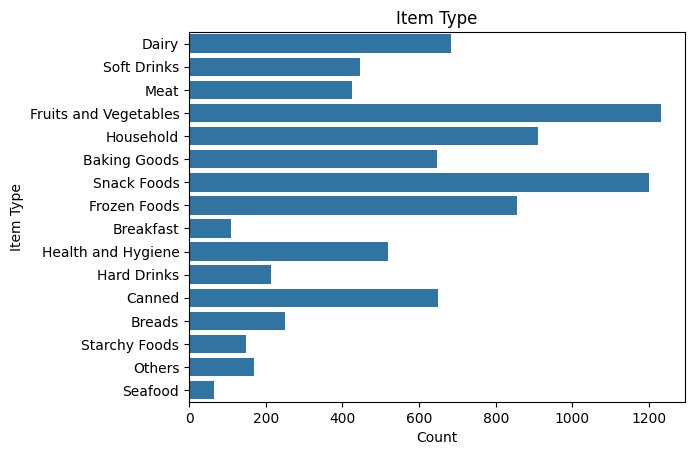

In [21]:
ax = sns.countplot(data= df_sales['Item_Type'])
ax.set_title('Item Type')
ax.set_ylabel('Item Type')
ax.set_xlabel('Count')


- Fruits and vegetables are the best selar

In [22]:
corr= df_sales.corr(numeric_only=True)
corr

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
Item_Weight,1.000000,-0.011620,0.025821,-0.008376,0.012088
Item_Visibility,-0.011620,1.000000,-0.001315,-0.074834,-0.128625
Item_MRP,0.025821,-0.001315,1.000000,0.005020,0.567574
Outlet_Establishment_Year,-0.008376,-0.074834,0.005020,1.000000,-0.049135
Item_Outlet_Sales,0.012088,-0.128625,0.567574,-0.049135,1.000000


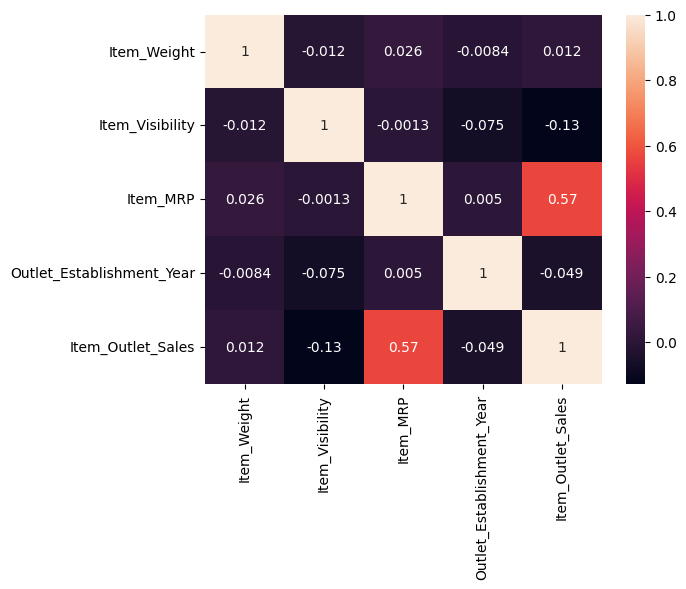

In [23]:
ax=sns.heatmap(corr, annot=True)

- There aren't really any strong correlations shown here
- There is a modarate postive correlation between the Item MRP and the Item outlet sales.
- All of the other correlations are negligible

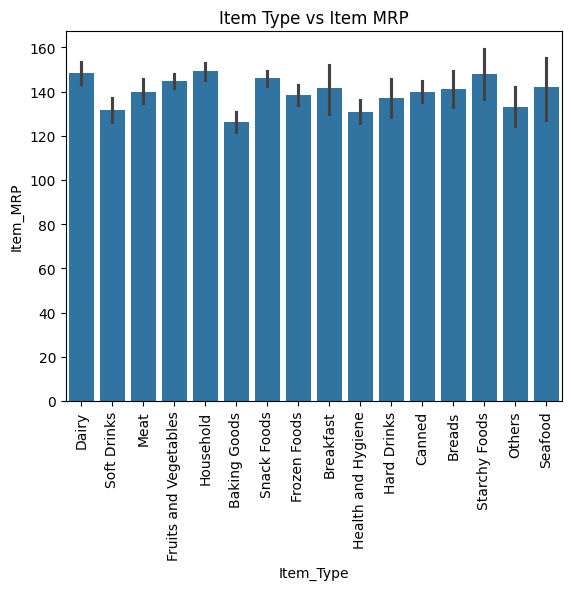

In [24]:
ax=sns.barplot(data=df_sales, x='Item_Type', y='Item_MRP')
ax.set_title('Item Type vs Item MRP')

ax=plt.xticks(rotation=90)


- Starchy foods have a max MRP

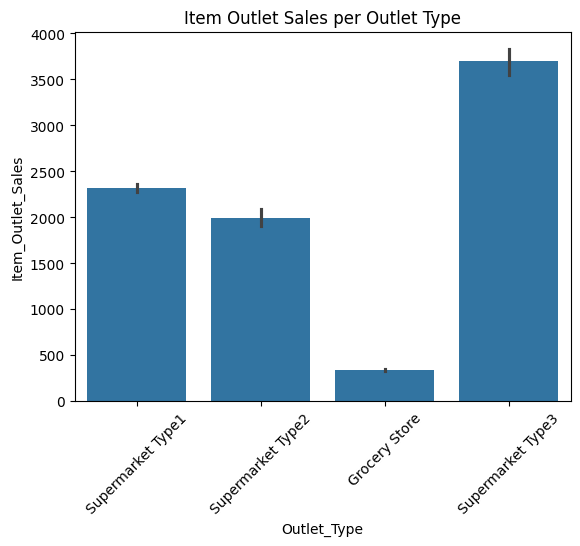

In [35]:
ax=sns.barplot(data=df_sales, x='Outlet_Type', y='Item_Outlet_Sales')
ax.set_title('Item Outlet Sales per Outlet Type')
ax=plt.xticks(rotation=45)

- Higher sales in supermarket type 3

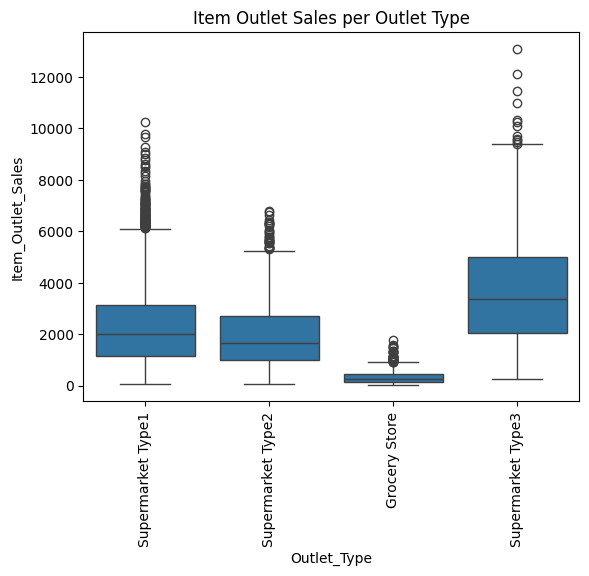

In [59]:
ax=sns.boxplot(data=df_sales, x='Outlet_Type', y='Item_Outlet_Sales')
ax.set_title('Item Outlet Sales per Outlet Type')
ax=plt.xticks(rotation=90)
